<a href="https://colab.research.google.com/github/alwhshalkasr267-design/FinalProject/blob/main/FinalProject_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Connect drive

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load Data

In [61]:
import os
import pandas as pd

folder_path = '/content/drive/MyDrive/Obstacles_dataset'
classes_names = os.listdir(folder_path)
print("Dataset Classes: ", classes_names)

Dataset Classes:  ['chair', 'door', 'fence', 'stairs', 'pothole', 'obstacle', 'table', 'plant', 'garbage_bin', 'vehicle']


In [62]:
i = 1
for folder in sorted(os.listdir(folder_path)):
    full_folder_path = os.path.join(folder_path, folder)
    if os.path.isdir(full_folder_path):
        num_images = len(os.listdir(full_folder_path))
        print(f"{i} Number of [{folder}] Class : {num_images} images")
        i += 1


1 Number of [chair] Class : 407 images
2 Number of [door] Class : 242 images
3 Number of [fence] Class : 179 images
4 Number of [garbage_bin] Class : 175 images
5 Number of [obstacle] Class : 423 images
6 Number of [plant] Class : 139 images
7 Number of [pothole] Class : 706 images
8 Number of [stairs] Class : 504 images
9 Number of [table] Class : 185 images
10 Number of [vehicle] Class : 604 images


In [65]:
images = []
labels = []

for label_indx, classes_name in enumerate(classes_names):
  class_dir = os.path.join(folder_path, classes_name)
  if os.path.isdir(class_dir):
        print(f"Class [{class_name}] is done ,  It got label number: {label_idx}")
        for file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, file)
            images.append(img_path)
            labels.append(str(label_indx))
print(f"Total images collected : {len(images)}")

Processing Class: chair -> Assigned Label: 0
Processing Class: door -> Assigned Label: 1
Processing Class: fence -> Assigned Label: 2
Processing Class: stairs -> Assigned Label: 3
Processing Class: pothole -> Assigned Label: 4
Processing Class: obstacle -> Assigned Label: 5
Processing Class: table -> Assigned Label: 6
Processing Class: plant -> Assigned Label: 7
Processing Class: garbage_bin -> Assigned Label: 8
Processing Class: vehicle -> Assigned Label: 9
Total images collected : 3564


In [54]:
img_size = (224, 224)
Batch_size = 32
data_generator = ImageDataGenerator(
    rescale=1./255,            # تحويل قيم البكسلات لتصبح بين 0 و 1
    rotation_range=20,         # تدوير عشوائي بزاوية 20 درجة لمكافحة زوايا تصوير الكفيف المتغيرة
    width_shift_range=0.2,     # إزاحة أفقية عشوائية
    height_shift_range=0.2,    # إزاحة عمودية عشوائية
    shear_range=0.15,          # قص عشوائي للزوايا
    zoom_range=0.2,            # تكبير/تصغير عشوائي
    horizontal_flip=True,      # قلب الصورة أفقياً (محاكاة الاتجاهات اليمين واليسار)
    validation_split=0.2       # حجز 20% من البيانات الإجمالية لأغراض التحقق والاختبار
)

In [30]:
# 1. مولد بيانات التدريب (Training Generator) - يأخذ حصة الـ 80%
train_generator = data_generator.flow_from_directory(
    folder_path,
    target_size=img_size,
    batch_size=Batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)
val_generator = data_generator.flow_from_directory(
    folder_path,
    target_size=img_size,
    batch_size=Batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)
print(f"Data Engineering complete. Classes mapped: {train_generator.class_indices}")

Found 2856 images belonging to 10 classes.
Found 708 images belonging to 10 classes.
Data Engineering complete. Classes mapped: {'chair': 0, 'door': 1, 'fence': 2, 'garbage_bin': 3, 'obstacle': 4, 'plant': 5, 'pothole': 6, 'stairs': 7, 'table': 8, 'vehicle': 9}


In [16]:

print(os.listdir(folder_path))

# تحميل بيانات التدريب (80%)
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(150, 150),
    batch_size=32
)

# تحميل بيانات الاختبار/التحقق (20%)
test_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(150, 150),
    batch_size=32
)

['chair', 'door', 'fence', 'stairs', 'pothole', 'obstacle', 'table', 'plant', 'garbage_bin', 'vehicle']


NameError: name 'image_dataset_from_directory' is not defined

In [12]:
import os
import pandas as pd
BASE_DIR = "/content/drive/MyDrive/Obstacles_dataset"
Chair_DIR = os.path.join(BASE_DIR, "chair")
Door_DIR = os.path.join(BASE_DIR, "door")
Fence_DIR = os.path.join(BASE_DIR, "fence")
Garbage_bin_DIR = os.path.join(BASE_DIR, "garbage_bin")
Obstacle_DIR = os.path.join(BASE_DIR, "obstacle")
Plant_DIR = os.path.join(BASE_DIR, "plant")
Pothole_DIR = os.path.join(BASE_DIR, "pothole")
Stairs_DIR = os.path.join(BASE_DIR, "stairs")
Table_DIR = os.path.join(BASE_DIR, "table")
Vehicle_DIR = os.path.join(BASE_DIR, "vehicle")


In [13]:
import os
print(os.listdir('/content/drive/MyDrive/Obstacles_dataset'))

['chair', 'door', 'fence', 'stairs', 'pothole', 'obstacle', 'table', 'plant', 'garbage_bin', 'vehicle']


NameError: name 'train_img' is not defined

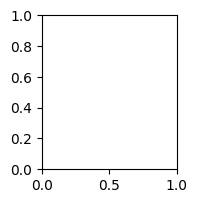

In [14]:
plt.figure(figsize=(8,2))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(train_img[i])
    plt.xlabel(my_classes[train_lab[i]])
    plt.xticks([])
    plt.yticks([])
plt.show()

In [ ]:
Chair_count = len(os.listdir(Chair_DIR))
Door_count = len(os.listdir(Door_DIR))
Fence_count = len(os.listdir(Fence_DIR))
Garbage_bin_count = len(os.listdir(Garbage_bin_DIR))
Obstacle_count = len(os.listdir(Obstacle_DIR))
Plant_count = len(os.listdir(Plant_DIR))
Pothole_count = len(os.listdir(Pothole_DIR))
Stairs_count = len(os.listdir(Stairs_DIR))
Table_count = len(os.listdir(Table_DIR))
Vehicle_count = len(os.listdir(Vehicle_DIR))


print ("Number of Chair images: ", Chair_count)
print ("Number of Door images: ", Door_count)
print ("Number of Fence images: ", Fence_count)
print ("Number of Garbage_bin images: ", Garbage_bin_count)
print ("Number of Obstacle images: ", Obstacle_count)
print ("Number of Plant images: ", Plant_count)
print ("Number of Pothole images: ", Pothole_count)
print ("Number of Stairs images: ", Stairs_count)
print ("Number of Table images: ", Table_count)
print ("Number of Vehicle images: ", Vehicle_count)

Number of Chair images:  407
Number of Door images:  242
Number of Fence images:  179
Number of Garbage_bin images:  175
Number of Obstacle images:  423
Number of Plant images:  139
Number of Pothole images:  706
Number of Stairs images:  504
Number of Table images:  185
Number of Vehicle images:  604


In [ ]:
images = []
labels = []

for file in os.listdir(Chair_DIR):
    images.append(os.path.join(Chair_DIR, file))
    labels.append("0") # Chair

for file in os.listdir(Door_DIR):
    images.append(os.path.join(Door_DIR, file))
    labels.append("1") # Door

for file in os.listdir(Fence_DIR):
    images.append(os.path.join(Fence_DIR, file))
    labels.append("2") # Fence

for file in os.listdir(Garbage_bin_DIR):
    images.append(os.path.join(Garbage_bin_DIR, file))
    labels.append("3") # Garbage_bin

for file in os.listdir(Obstacle_DIR):
    images.append(os.path.join(Obstacle_DIR, file))
    labels.append("4") # Obstacle

for file in os.listdir(Plant_DIR):
    images.append(os.path.join(Plant_DIR, file))
    labels.append("5") # Plant

for file in os.listdir(Pothole_DIR):
    images.append(os.path.join(Pothole_DIR, file))
    labels.append("6") # Pothole

for file in os.listdir(Stairs_DIR):
    images.append(os.path.join(Stairs_DIR, file))
    labels.append("7") # Stairs

for file in os.listdir(Table_DIR):
    images.append(os.path.join(Table_DIR, file))
    labels.append("8") # Table

for file in os.listdir(Vehicle_DIR):
    images.append(os.path.join(Vehicle_DIR, file))
    labels.append("9") # Vehicle

df = pd.DataFrame({
"image" : images ,
"label" : labels
})
df = df.sample(frac=1).reset_index(drop=True) # Mixing up the raws
df.head(20)


,image,label
0,/content/drive/MyDrive/Obstacles_dataset/door/...,1
1,/content/drive/MyDrive/Obstacles_dataset/stair...,7
2,/content/drive/MyDrive/Obstacles_dataset/table...,8
3,/content/drive/MyDrive/Obstacles_dataset/vehic...,9
4,/content/drive/MyDrive/Obstacles_dataset/potho...,6
5,/content/drive/MyDrive/Obstacles_dataset/chair...,0
6,/content/drive/MyDrive/Obstacles_dataset/potho...,6
7,/content/drive/MyDrive/Obstacles_dataset/vehic...,9
8,/content/drive/MyDrive/Obstacles_dataset/potho...,6
9,/content/drive/MyDrive/Obstacles_dataset/fence...,2


In [ ]:
import os

# حدد مسار المجلد الرئيسي هنا
BASE_DIR = '/content/drive/MyDrive/Obstacles_dataset'

total_images = 0
total_garbage_files = 0

for root, dirs, files in os.walk(BASE_DIR):
    for file in files:
        # التأكد من أن الملف هو صورة فعلاً بامتداد معروف
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            total_images += 1
        else:
            total_garbage_files += 1

print(f"عدد الصور الحقيقية الفعلي: {total_images}")
print(f"عدد الملفات الأخرى الزائدة (نصوص أو ملفات نظام): {total_garbage_files}")

عدد الصور الحقيقية الفعلي: 3564
عدد الملفات الأخرى الزائدة (نصوص أو ملفات نظام): 0


In [ ]:
from PIL import Image
from tqdm import tqdm

bad = []

for p in tqdm(df['image']):
  try:
    with Image.open(p) as im:
      im.load()
  except:
        bad.append(p)

print("Bad images: ", len(bad))

df = df[~df['image'].isin(bad)].reset_index(drop=True)
print("Remaining images: ",len(df))

NameError: name 'df' is not defined

In [ ]:
+import os
import shutil
from sklearn.model_selection import train_test_split

data_dir = BASE_DIR
train_dir = "dataset/train"
val_dir = "dataset/val"
test_dir = "dataset/test"

val_ratio = 0.15
test_ratio = 0.15

classes = os.listdir(data_dir)

for cls in classes:
    src_cls_dir = os.path.join(data_dir, cls)
    if not os.path.isdir(src_cls_dir):
        continue

    images = os.listdir(src_cls_dir)

    train_val_images, test_images = train_test_split(images, test_size=test_ratio, random_state=42)

    relative_val_ratio = val_ratio /(1-test_ratio)
    train_images, val_images = train_test_split(
         train_val_images, test_size=relative_val_ratio,random_state=42
    )

    for split_dir , split_images in zip(
        [train_dir, val_dir, test_dir], [train_images, val_images, test_images]):
      dset_dir = os.path.join(split_dir, cls)
      os.makedirs(dset_dir, exist_ok=True)

      for img in split_images:
        shutil.copy(os.path.join(src_cls_dir, img), os.path.join(dset_dir, img))

print("تم تقسيم البيانات بنجاح ")


تم تقسيم البيانات بنجاح 
